<a href="https://colab.research.google.com/github/serendipity343/Machine-learning/blob/Task-1%262/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This colab worksheet provides a starting point for Task 1 (the natural language processing assignment).

In [ ]:
import google
google.colab.drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import necessary packages

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the data using np.load
data = pd.read_csv('/content/drive/MyDrive/350/spam_detection_training_data.csv')

# Extract the text
text = data['text'].values
# And the labels
labels = data['label'].values
text = np.array([t.lower().replace(r'[^a-z ]', '') for t in text])
print(text.shape, labels.shape)

test_data = pd.read_csv('/content/drive/MyDrive/350/spam_detection_test_data.csv')
test_text = test_data['text'].values
print(test_text.shape)

(3619,) (3619,)
(1552,)


# Data Visualisation
Here's an example of how to display the text based on its label.

In [ ]:
# Define a function to print text with its spam classification label
def print_text(text, label):
    """
    Prints the given text with its spam classification.

    Parameters:
    text (str): The text message to be printed
    label (int): The classification label (0 = not spam, 1 = spam)
    """
    if label == 0:
        # Print text followed by "not spam" message
        print(text, '\nis not spam!')
    else:
        # Print text followed by "spam" message
        print(text, '\nis spam!')

# Import numpy library for random number generation
import numpy as np

# Generate a random index to select a sample from the dataset
# text.shape[0] gives the total number of samples in the dataset
idx = np.random.randint(0, text.shape[0])

# Print a randomly selected text with its label using the print_text function
print_text(text[idx], labels[idx])

subject: epgt
clarissa - thanks so much for all your help with this pipe ! everything looks great . i just have a couple of paths
that i need to finish it :
january 2000 - i need deal # 854688 pathed for epgt and for tetc . according to the invoice , we should have
11 , 129 dth on the interconnect .
february 2000 - i need deal # 871184 pathed for hpl and chan . hpl should have 3 , 600 dth and chan should
have 11 , 500 dth on the interconnect .
july 2000 - deal # 871172 has an interconnect issue . according to mops contract # 105124 , they received 8 , 275 dth
on the matagorda 624 , but according to epgt , they delivered 10 , 362 dth to hpl ( ? ) could this possibly
need to be split somehow , or do you have any other ideas ?
let me know . thanks , gloria 3 - 7118 
is not spam!


# Data Processing

In [ ]:
# Preprocess training text
text = np.array([t.lower().replace(r'[^a-z ]', '') for t in text])
# Preprocess test text
test_text = np.array([t.lower().replace(r'[^a-z ]', '') for t in test_text])

In [ ]:
# Split Training Data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    text, labels, test_size=0.2, random_state=42
)

In [ ]:
# Feature Extraction with TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf_vectorizer.fit_transform(train_texts)
X_val = tfidf_vectorizer.transform(val_texts)

In [ ]:
# Define the models: Naive Bayes, Logistic Regression, Random Forest
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
predictions = {}

In [ ]:
# Training all models in the models dictionary
for name, model in models.items():
    # Print which model is currently being trained
    print(f"\nTraining {name}:")

    # Train the current model on training data
    model.fit(X_train, train_labels)

    # Make predictions on validation set
    preds = model.predict(X_val)

    # Store predictions in predictions dictionary
    predictions[name] = preds

    # Calculate evaluation metrics and store in results dictionary
    results[name] = {
        'Accuracy': accuracy_score(val_labels, preds),
        'Precision': precision_score(val_labels, preds),
        'Recall': recall_score(val_labels, preds),
        'F1': f1_score(val_labels, preds)
    }

    # Print validation accuracy for the current model
    print(f"{name} Validation Accuracy: {results[name]['Accuracy']:.4f}")

# Model Comparison
# Convert results dictionary to pandas DataFrame and transpose it
# This creates a nice table with models as rows and metrics as columns
metrics_df = pd.DataFrame(results).T

# Print the comparison table
print(metrics_df)


Training Naive Bayes:
Naive Bayes Validation Accuracy: 0.9599

Training Logistic Regression:
Logistic Regression Validation Accuracy: 0.9793

Training Random Forest:
Random Forest Validation Accuracy: 0.9655
                     Accuracy  Precision    Recall        F1
Naive Bayes          0.959945   0.907895  0.962791  0.934537
Logistic Regression  0.979282   0.954545  0.976744  0.965517
Random Forest        0.965470   0.924107  0.962791  0.943052


<Figure size 1000x600 with 0 Axes>

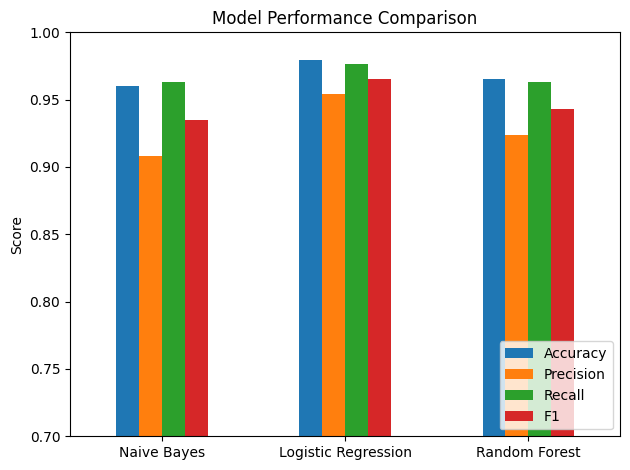

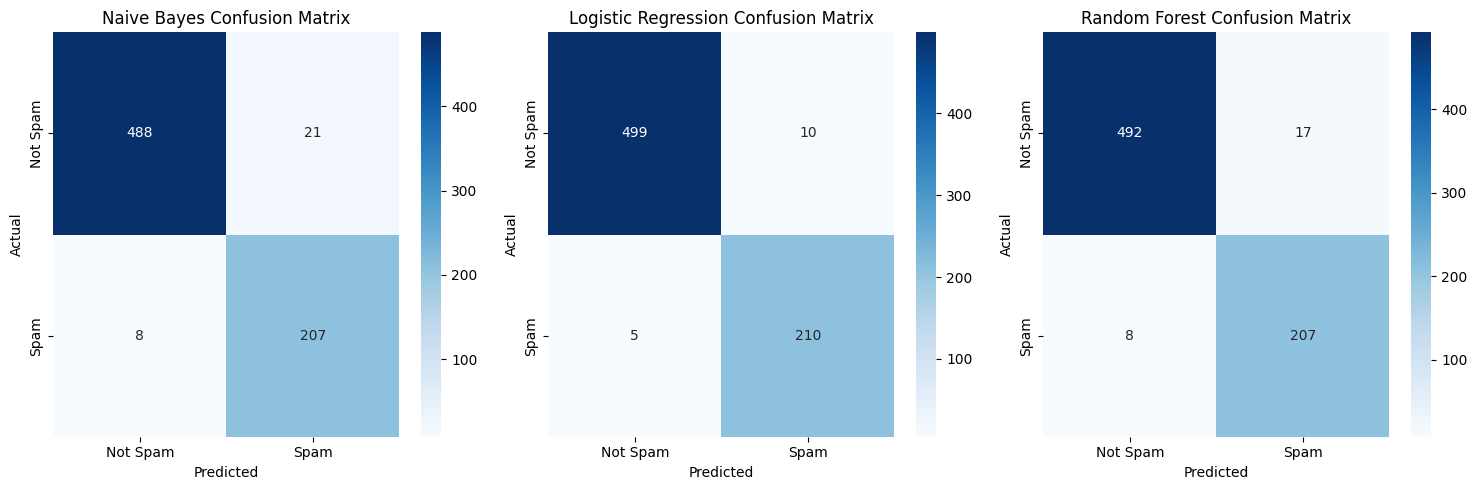

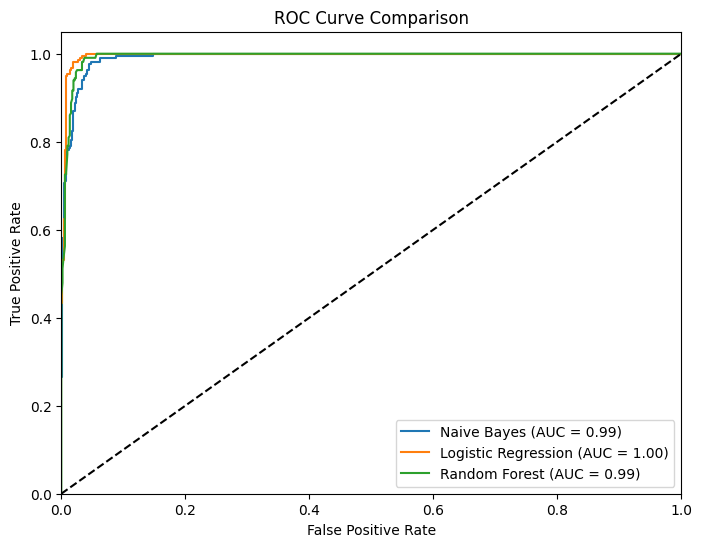

In [ ]:
# 1. Performance Metrics Comparison Bar Chart
plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar', rot=0)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 2. Confusion Matrix Visualization
plt.figure(figsize=(15, 5))
for i, (name, preds) in enumerate(predictions.items(), 1):
    plt.subplot(1, 3, i)

    # Calculate confusion matrix
    cm = confusion_matrix(val_labels, preds)

    # Create heatmap visualization of confusion matrix
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Not Spam', 'Spam'],
                yticklabels=['Not Spam', 'Spam'])

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# 3. ROC Curve Comparison (for models that support probability predictions)
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # Get predicted probabilities for positive class (spam)
        probs = model.predict_proba(X_val)[:, 1]

        # Calculate ROC curve metrics
        fpr, tpr, _ = roc_curve(val_labels, probs)
        roc_auc = auc(fpr, tpr)  # Calculate AUC score

        # Plot ROC curve with AUC in label
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Add diagonal reference line (random classifier performance)
plt.plot([0, 1], [0, 1], 'k--')

# Set axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend(loc='lower right')
plt.show()

# Analyze Errors for All MODELS

In [ ]:
def analyze_errors(model_name, texts, true_labels, pred_labels):
    """
    Analyzes and displays misclassified examples for a given model.

    Parameters:
        model_name (str): Name of the model being analyzed
        texts (array): Array of text samples
        true_labels (array): Ground truth labels
        pred_labels (array): Model's predicted labels

    Returns:
        DataFrame containing all misclassified examples
    """
    # Create DataFrame with texts and labels
    errors = pd.DataFrame({
        'text': texts,
        'true_label': true_labels,
        'pred_label': pred_labels
    })

    # Filter to only misclassified examples
    errors = errors[errors['true_label'] != errors['pred_label']]

    # Print top 3 errors with truncated text
    print(f"\n{model_name} - Top 3 Misclassified Examples:")
    for i, row in errors.head(3).iterrows():
        print(f"\nText: {row['text'][:100]}...")
        print(f"True: {'Spam' if row['true_label'] else 'Not Spam'}")
        print(f"Predicted: {'Spam' if row['pred_label'] else 'Not Spam'}")

    return errors

# Analyze errors for all models
errors = {}
for name, preds in predictions.items():
    errors[name] = analyze_errors(name, val_texts, val_labels, preds)
print('Failure cases saved to failure_cases')


Naive Bayes - Top 3 Misclassified Examples:

Text: subject: holiday party - save the date
please click on the link below
save the date...
True: Not Spam
Predicted: Spam

Text: subject: dear all
if you wish to find out more about the mission in
kosovo , you can find news and...
True: Not Spam
Predicted: Spam

Text: subject: fw : gop action plan : what you can do !
- - - - - original message - - - - -
from : alex...
True: Not Spam
Predicted: Spam

Logistic Regression - Top 3 Misclassified Examples:

Text: subject: holiday party - save the date
please click on the link below
save the date...
True: Not Spam
Predicted: Spam

Text: subject: dear all
if you wish to find out more about the mission in
kosovo , you can find news and...
True: Not Spam
Predicted: Spam

Text: subject: re : boat
i checked the boat and it is 17 ft , 7 in . long , it is a capri model # 1750 ch...
True: Not Spam
Predicted: Spam

Random Forest - Top 3 Misclassified Examples:

Text: subject: holiday party - save the dat

# Test Set Predictions

In [ ]:
# Load and preprocess test data
test_data = pd.read_csv('/content/drive/MyDrive/350/spam_detection_test_data.csv')
test_texts = test_data['text'].values
test_texts = np.array([t.lower().replace(r'[^a-z ]', '') for t in test_texts])

# Transform test data using same vectorizer
X_test = tfidf_vectorizer.transform(test_texts)

# Generate and save predictions for each model
for name, model in models.items():
    test_preds = model.predict(X_test)
    # Save predictions with model name in filename
    np.savetxt(f'/content/drive/MyDrive/350/{name.lower().replace(" ", "_")}_predictions.csv',
               test_preds, delimiter=',')
    print(f"\n{name} test predictions saved")



Naive Bayes test predictions saved

Logistic Regression test predictions saved

Random Forest test predictions saved


# The Time Comparison of All Models


 Training Time Benchmark:
----------------------------------------
Naive Bayes          0.00 seconds
Logistic Regression  0.03 seconds
Random Forest        1.05 seconds


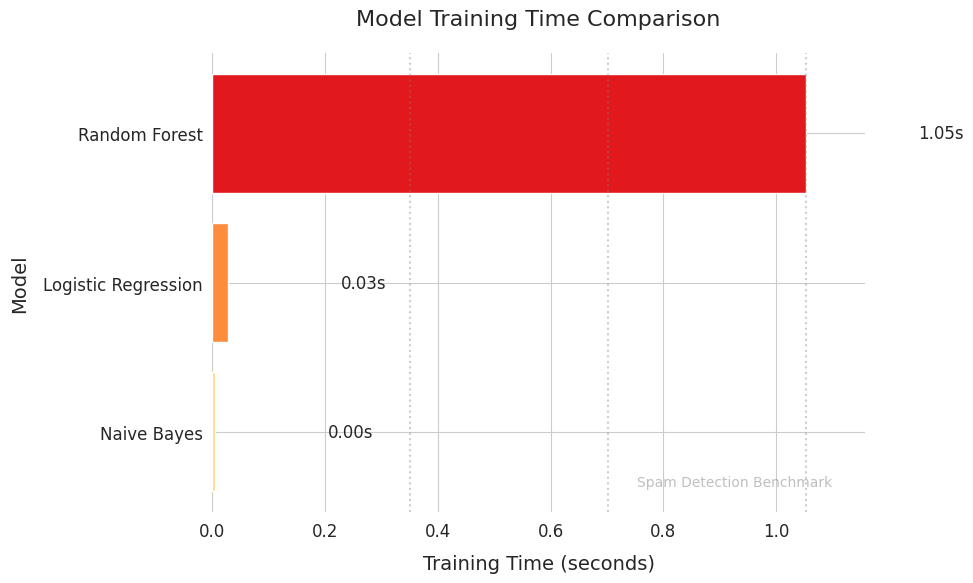

In [ ]:
# Training Time Comparison with Enhanced Visualization
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14

# Time the training process for each model
time_results = {}
print("\n Training Time Benchmark:")
print("-"*40)

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, train_labels)
    elapsed = time.time() - start_time
    time_results[name] = elapsed

    # Print with colored output
    if elapsed > 10:
        color_code = '\033[91m'  # Red for slow models
    elif elapsed > 5:
        color_code = '\033[93m'  # Yellow for moderate
    else:
        color_code = '\033[92m'  # Green for fast
    print(f"{name:<20} {color_code}{elapsed:.2f} seconds\033[0m")

# Create beautiful visualization
plt.figure(figsize=(10, 6), dpi=100)

# Create gradient-colored bars
colors = sns.color_palette("YlOrRd", len(time_results))
bars = plt.barh(list(time_results.keys()),
                list(time_results.values()),
                color=colors)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}s',
             va='center', ha='left', fontsize=12)

# Styling
plt.title('Model Training Time Comparison', pad=20, fontsize=16)
plt.xlabel('Training Time (seconds)', labelpad=10)
plt.ylabel('Model', labelpad=10)
plt.xlim(0, max(time_results.values())*1.1)  # Add 10% padding

# Add reference lines
max_time = max(time_results.values())
for t in [max_time/3, max_time*2/3, max_time]:
    plt.axvline(x=t, color='gray', linestyle=':', alpha=0.4)

# Remove spines for cleaner look
sns.despine(left=True, bottom=True)

# Add watermark
plt.text(0.95, 0.05, 'Spam Detection Benchmark',
         fontsize=10, color='gray', alpha=0.5,
         ha='right', va='bottom', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()